# COSC2753 Assignment 2 - Fashion Intelligence System

# COSC2753 Assignment 2 — Fashion Intelligence System

## Group 8:
- s3927120 - Vu Quoc Gia Quan
- s4225113 - Yoshita Sarin
- s4232487 - Do Tien Thinh
- s4064843 - Tin Nguyen Trong

# Data Preprocessing (Tasks 1-3)

One notebook that prepares the data for:
- **Task 1** — predict `articleType`
- **Task 2** — predict `season`
- **Task 3** — predict `gender` and `usage`

**What's in this notebook:**
1. Import libraries
2. Load the dataset
3. Look at the CSV and the images
4. Split into train and validation
5. Explore the train data
6. Process the data, and explain each decision per task

**Our plan:** clean and understand the raw fashion dataset once, here, so every downstream task (articleType, season, gender, usage classification) reuses the same trustworthy, leak-free split and the same fitted preprocessing objects, rather than each task re-deriving its own.

## 1. Import Libraries

In [1]:
import os
import json
import pickle
import hashlib
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy.stats import chi2_contingency

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, f1_score

import torch
from torch.utils.data import Dataset, WeightedRandomSampler
import torchvision.transforms as T

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', None)

## 2. Load Dataset

**Our approach:** confirm every raw data path exists before reading anything from it.

In [2]:
DATA_DIR = Path("../data/raw/FashionDataset")
OUT_DIR = Path("../data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATA_DIR / "train" / "styles_train.csv"
IMAGES_TRAIN_DIR = DATA_DIR / "train" / "images_train"
TEST_PRED_CSV = DATA_DIR / "test" / "styles_prediction.csv"
IMAGES_TEST_DIR = DATA_DIR / "test" / "images_test"

for p in [TRAIN_CSV, IMAGES_TRAIN_DIR, TEST_PRED_CSV, IMAGES_TEST_DIR]:
    print(f"[{'OK' if p.exists() else 'MISSING'}] {p}")

[OK] ../data/raw/FashionDataset/train/styles_train.csv
[OK] ../data/raw/FashionDataset/train/images_train
[OK] ../data/raw/FashionDataset/test/styles_prediction.csv
[OK] ../data/raw/FashionDataset/test/images_test


**Result:** all four paths (train CSV, train images, test CSV, test images) found and confirmed present.

**Next:** load the raw CSV and check it against its own documentation.

## 3. Looking at `styles_train.csv` and the Images

**Our approach:** check the CSV and the actual image files against each other directly -- malformed columns, rows with no matching photo, corrupt files, exact-duplicate images -- before doing any real analysis on data that might not be trustworthy yet.

### 3.1 First look at the CSV

**Our approach:** load the raw CSV and look at its actual shape and columns.

In [3]:
df = pd.read_csv(TRAIN_CSV)
print(df.columns.tolist())
print(df.shape)
df.head(3)

['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'Unnamed: 10', 'Unnamed: 11']
(38617, 12)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,Unnamed: 10,Unnamed: 11
0,1163,Men,Apparel,Topwear,Tshirts,Blue,Summer,2011,Sports,Nike Sahara Team India Fanwear Round Neck Jersey,NaN,NaN
1,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,NaN,NaN
2,1165,Men,Apparel,Topwear,Tshirts,Blue,Summer,2013,Sports,Nike Mean Team India Cricket Jersey,NaN,NaN


In [4]:
# The raw CSV has stray commas in some rows, which pandas turns into extra
# 'Unnamed: N' columns. Drop them.
unnamed_cols = df.columns[df.columns.str.startswith('Unnamed')].tolist()
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
print(f"Dropped {len(unnamed_cols)} malformed column(s): {unnamed_cols}")
print(df.columns.tolist())
print(df.shape)

Dropped 2 malformed column(s): ['Unnamed: 10', 'Unnamed: 11']
['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']
(38617, 10)


**Result:** 38,617 rows, 12 columns -- including two unnamed, entirely empty columns (`Unnamed: 10`, `Unnamed: 11`), likely from stray trailing commas in the source file. Both dropped, leaving 10 real columns.

**What this tells us:** the raw file needs a small amount of cleanup before it's trustworthy, but nothing structurally wrong with the data itself.

**Next:** check every CSV row against the actual image files on disk.

### 3.2 Image to CSV alignment (full dataset, before any split)

**Our approach:** cross-reference every CSV row's `id` against the actual files present in the images folder, in both directions.

In [5]:
csv_ids = set(df['id'].astype(str))
disk_ids = {p.stem for p in IMAGES_TRAIN_DIR.glob("*.jpg")}

missing_images = sorted(csv_ids - disk_ids)   # CSV rows with no image file
extra_images = sorted(disk_ids - csv_ids)     # image files with no CSV row

print(f"CSV rows with no image file: {len(missing_images)} -> {missing_images}")
print(f"Image files with no CSV row: {len(extra_images)}")

CSV rows with no image file: 5 -> ['12347', '39401', '39403', '39410', '39425']
Image files with no CSV row: 0


In [6]:
# Drop the unmatched rows now, before the split, so 'df' and its image folder
# stay aligned for every downstream step (EDA, split, processing).
df = df[~df['id'].astype(str).isin(missing_images)].reset_index(drop=True)
df['id'] = df['id'].astype(str).str.strip()
print(f"Remaining rows: {df.shape[0]}")

Remaining rows: 38612


**Result:** 5 CSV rows have no matching image file; no image files are missing a CSV row. The 5 unmatched rows are dropped, leaving 38,612 rows -- every remaining row is backed by a real, loadable image.

**What this tells us:** the mismatch is small and one-directional (a few CSV entries reference photos that were never provided), not a sign of a broader data-quality problem.

**Next:** check the remaining images for corruption and exact duplicates.

### 3.3 Image integrity: corrupt files and exact duplicates

**Our approach:** attempt to open every remaining image file, and separately hash every image's raw bytes to find exact byte-for-byte duplicates -- two different problems that need checking independently. Duplicate images matter specifically because of the split coming next: if a duplicate ends up on one side and its twin on the other, a model would effectively be validated on a photo it already trained on.

In [7]:
# Corrupt / unopenable images
corrupt = []
for img_id in df['id']:
    try:
        with Image.open(IMAGES_TRAIN_DIR / f"{img_id}.jpg") as im:
            im.verify()
    except Exception as e:
        corrupt.append((img_id, str(e)))

print(f"Corrupt/unopenable images: {len(corrupt)}")
for img_id, err in corrupt[:10]:
    print(f"  {img_id}: {err}")

Corrupt/unopenable images: 0


In [8]:
# Exact duplicate images (byte-for-byte, via md5 hash). The resulting 'dup_group'
# is needed later: it's what the train/val split is grouped on, so two copies of
# the same product photo can never end up on opposite sides of the split.
def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hash_to_group = {}
group_ids = []
for img_id in df['id']:
    h = file_hash(IMAGES_TRAIN_DIR / f"{img_id}.jpg")
    if h not in hash_to_group:
        hash_to_group[h] = img_id       # first id seen becomes the group label
    group_ids.append(hash_to_group[h])

df['dup_group'] = group_ids
n_groups = df['dup_group'].nunique()
n_dupe_rows = len(df) - n_groups
print(f"{n_groups} unique image groups out of {len(df)} rows "
      f"({n_dupe_rows} rows are exact duplicates of another row)")

37849 unique image groups out of 38612 rows (763 rows are exact duplicates of another row)


In [9]:
for target in ['articleType', 'gender', 'season', 'usage']:
    label_conflicts = df.groupby('dup_group')[target].nunique(dropna=False)
    conflicting_groups = label_conflicts[label_conflicts > 1]
    print(f"{target}: {len(conflicting_groups)} of {n_groups} groups have inconsistent labels")

articleType: 7 of 37849 groups have inconsistent labels
gender: 7 of 37849 groups have inconsistent labels
season: 8 of 37849 groups have inconsistent labels
usage: 3 of 37849 groups have inconsistent labels


In [10]:
conflict_ids = set()
for target in ['articleType', 'gender', 'season', 'usage']:
    lc = df.groupby('dup_group')[target].nunique(dropna=False)
    conflict_ids |= set(lc[lc > 1].index)

print(f"{len(conflict_ids)} distinct dup_groups have a conflict in at least one target")

20 distinct dup_groups have a conflict in at least one target


**Removing duplicates now, before the split.** Keeping every copy of a duplicated photo and only grouping around it at split time (so copies stay together) still leaves those copies inflating whichever categories happen to be duplicated more, unevenly, in the training data. Removing them here instead means the split works with one row per genuinely distinct image, and the reported dataset size is the real number of unique products, not inflated by exact copies.

Two separate decisions, since they're not the same problem:

- **Groups with conflicting labels** (the same photo tagged differently across its copies) get dropped entirely -- there's no way to know which label is correct, so keeping either one would be guessing.
- **Groups with consistent labels** keep exactly one representative row; the redundant copies are dropped.

In [11]:
# Step 1: drop every row belonging to a label-conflicting group entirely --
# none of those rows can be trusted, not just the "extra" copies.
n_conflicting_rows = df['dup_group'].isin(conflict_ids).sum()
df = df[~df['dup_group'].isin(conflict_ids)].reset_index(drop=True)
print(f"Dropped {n_conflicting_rows} row(s) in {len(conflict_ids)} label-conflicting groups")


Dropped 41 row(s) in 20 label-conflicting groups


In [12]:
# Step 2: for the remaining (now conflict-free) duplicate groups, keep exactly
# one representative row per group -- the first occurrence -- and drop the rest.
before_step2 = len(df)
df = df.drop_duplicates(subset='dup_group', keep='first').reset_index(drop=True)
print(f"Dropped {before_step2 - len(df)} redundant copy row(s)")
print(f"Rows remaining (one per unique image): {len(df)}")

# Every remaining dup_group now maps to exactly one row -- confirms nothing
# was missed and no conflicting group slipped through.
assert df['dup_group'].is_unique, "a dup_group still has more than one row after dedup"
assert set(df['dup_group']).isdisjoint(conflict_ids), "a conflicting group survived dedup"


Dropped 742 redundant copy row(s)
Rows remaining (one per unique image): 37829


**Result:** zero corrupt images. 37,849 unique image groups found out of 38,612 rows (763 rows are exact duplicates of another row); of those groups, 20 have a genuine label conflict across the four target columns (7 for `articleType`, 7 for `gender`, 8 for `season`, 3 for `usage`). Dropping the 20 conflicting groups entirely removes 41 rows; collapsing the remaining duplicate groups to one representative row each removes another 742 rows -- leaving 37,829 rows, one per genuinely unique image.

**What this tells us:** the vast majority of duplicates (742 of 763) are harmless exact copies with agreeing labels -- straightforward to collapse. The small remainder (41 rows across 20 groups) genuinely can't be trusted, since the same pixels were given two different answers and nothing in the data says which is right.

**Next:** with the dataset de-duplicated, run a quick visual sanity check before trusting it for the split.

### 3.4 Quick visual sanity check

**Our approach:** display a random sample of images alongside their labels, as a final human eyeball check before trusting the cleaned data for the split and everything after it.

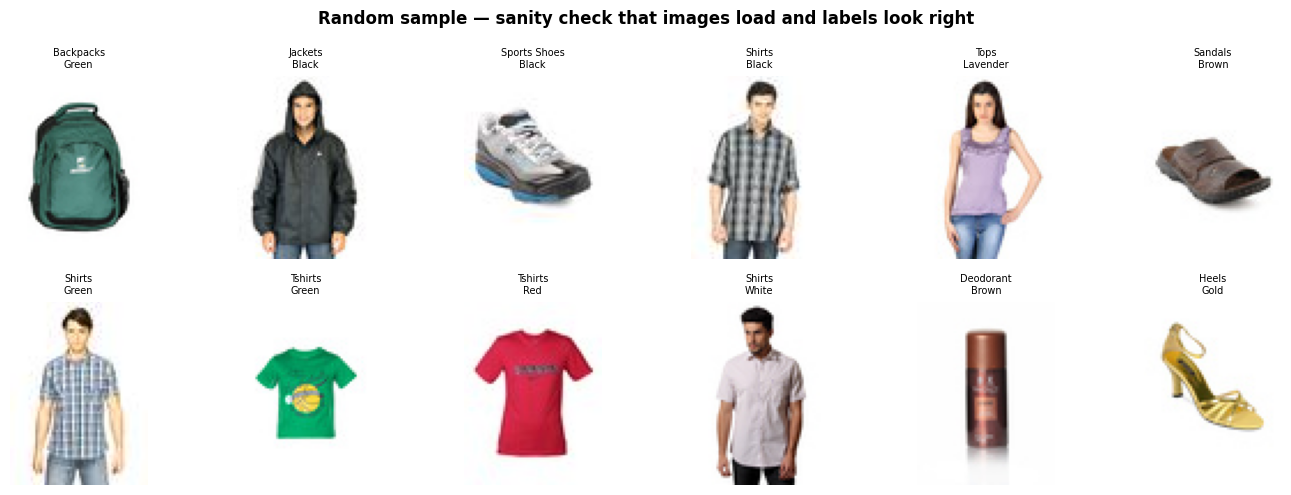

In [13]:
sample = df.sample(12, random_state=RANDOM_STATE)
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax, (_, r) in zip(axes.flat, sample.iterrows()):
    ax.imshow(Image.open(IMAGES_TRAIN_DIR / f"{r['id']}.jpg"))
    ax.axis("off")
    ax.set_title(f"{r['articleType']}\n{r['baseColour']}", fontsize=7)
fig.suptitle("Random sample — sanity check that images load and labels look right", fontweight="bold")
plt.tight_layout()
plt.show()

**Next:** with the dataset de-duplicated and verified, perform the actual train/validation split.

## 4. Train / Validation Split

**Duplicates are already handled at this point.** The exact-duplicate images identified in Section 3.3 were removed above -- label-conflicting groups dropped entirely, and one representative row kept per remaining duplicate group -- so every row here corresponds to a genuinely distinct photo. `dup_group` is still passed to the split below as a safety net (each group is now just a single row, so this has no practical effect on the current data), rather than as the primary defense against duplicate leakage.

**Why we split on `masterCategory`, not `articleType`:** `articleType` has a lot of rare classes. To split evenly on it, we'd first need to decide which classes count as "rare" -- and if we work that out using the full dataset (train and validation together), we'd be using validation labels to help set up training. `masterCategory` avoids this problem entirely, since it only has a handful of well-represented categories.

**What we do:** one `StratifiedGroupKFold` split (about 75/25), stratified on `masterCategory`, grouped on `dup_group`. Only one split, not full cross-validation -- with ~28,000+ rows this is enough data for a stable result, and 4-fold cross-validation would mean training every model four times over.

### 4.1 Doing the split

**Our approach:** apply the split, dropping any `masterCategory` value with fewer rows than the number of folds first -- a category that small can't be divided across train and validation at all, and since `masterCategory` isn't a prediction target for any task, this is a mechanical fix, not a modeling decision.

In [14]:
sgkf = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)  # 1 fold ~= 25%

# masterCategory needs at least n_splits rows per category for a clean split. A category
# with fewer rows than that can't be divided properly and ends up placed by chance --
# drop those rows first rather than let that happen silently.
master_counts = df['masterCategory'].value_counts()
too_rare_master = master_counts[master_counts < sgkf.get_n_splits()].index
if len(too_rare_master):
    n_dropped = df['masterCategory'].isin(too_rare_master).sum()
    print(f"Dropping {n_dropped} row(s) with a masterCategory that has fewer than "
          f"{sgkf.get_n_splits()} samples total: {list(too_rare_master)}")
    df = df[~df['masterCategory'].isin(too_rare_master)].reset_index(drop=True)

train_idx, val_idx = next(sgkf.split(df, df['masterCategory'], groups=df['dup_group']))
train_data = df.iloc[train_idx].reset_index(drop=True)
val_data = df.iloc[val_idx].reset_index(drop=True)

print(f"Train: {train_data.shape[0]}, Val: {val_data.shape[0]}")

# --- sanity checks ---
overlap = set(train_data['dup_group']) & set(val_data['dup_group'])
print(f"Duplicate-image groups appearing in BOTH splits: {len(overlap)} (should be 0)")

missing_master = set(df['masterCategory'].unique()) - set(train_data['masterCategory'].unique())
print(f"masterCategory classes missing from train: {missing_master if missing_master else 'none'}")

Dropping 1 row(s) with a masterCategory that has fewer than 4 samples total: ['Home']
Train: 28371, Val: 9457
Duplicate-image groups appearing in BOTH splits: 0 (should be 0)
masterCategory classes missing from train: none


**Result:** one row (`masterCategory` = 'Home') dropped for having fewer than 4 samples total. The split produces 28,371 training rows and 9,457 validation rows, with zero duplicate-image-group overlap between them and every `masterCategory` class present in both sides.

**What this tells us:** the split is leak-free and structurally sound -- no photo, or a near-duplicate of one, can appear on both sides, and every downstream task can build on this exact split with confidence.

**Next:** with the split fixed, explore the training data specifically.

## 5. Exploring the Train Data

**Our approach:** now that the split is fixed, look at the training data -- structure, missing values, category distributions, imbalance -- so every later preprocessing decision (imputation, rare-class handling) is grounded in what the training data actually looks like, not the full pre-split dataset.

### 5.1 Structure & overview

**Our approach:** look at the training split's shape, columns, and dtypes.

In [15]:
print(train_data.columns.tolist())
print(train_data.shape)
train_data.head()

['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'dup_group']
(28371, 11)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,dup_group
0,1163,Men,Apparel,Topwear,Tshirts,Blue,Summer,2011,Sports,Nike Sahara Team India Fanwear Round Neck Jersey,1163
1,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,1164
2,1526,Unisex,Accessories,Bags,Backpacks,Black,Fall,2010,Sports,Puma Big Cat Backpack Black,1526
3,1528,Men,Apparel,Topwear,Jackets,Black,Fall,2010,Sports,Puma Men Ferrari Black Fleece Jacket,1528
4,1529,Men,Apparel,Topwear,Tshirts,Red,Fall,2010,Casual,Ferrari Tee,1529


In [16]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 28371 entries, 0 to 28370
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id                  28371 non-null  str  
 1   gender              28371 non-null  str  
 2   masterCategory      28371 non-null  str  
 3   subCategory         28371 non-null  str  
 4   articleType         28371 non-null  str  
 5   baseColour          28360 non-null  str  
 6   season              28357 non-null  str  
 7   year                28371 non-null  int64
 8   usage               28315 non-null  str  
 9   productDisplayName  28366 non-null  str  
 10  dup_group           28371 non-null  str  
dtypes: int64(1), str(10)
memory usage: 2.4 MB


**Result:** 28,371 rows, 11 columns.

**Next:** check for missing values, since several columns (`baseColour`, `season`, `usage`) are known to have some.

### 5.2 Missing values

**Our approach:** count missing values per column in the training data specifically, to know what imputation strategy each affected column will need.

In [17]:
missing = train_data.isnull().sum()
missing_pct = (missing / len(train_data)) * 100
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct.round(2)}).sort_values('missing', ascending=False)
missing_df

,missing,pct
usage,56,0.20
season,14,0.05
baseColour,11,0.04
productDisplayName,5,0.02
id,0,0.00
gender,0,0.00
masterCategory,0,0.00
subCategory,0,0.00
articleType,0,0.00
year,0,0.00


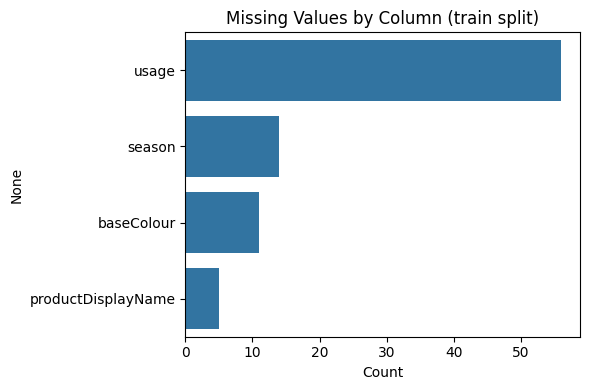

In [18]:
nonzero_missing = missing[missing > 0].sort_values(ascending=False)
if len(nonzero_missing):
    plt.figure(figsize=(6, 4))
    sns.barplot(x=nonzero_missing.values, y=nonzero_missing.index)
    plt.title('Missing Values by Column (train split)')
    plt.xlabel('Count')
    plt.tight_layout()
    plt.show()

**Result:** `usage` has 56 missing (0.20%), `season` 14 (0.05%), `baseColour` 11 (0.04%), `productDisplayName` 5 (0.02%). Every other column, including all four id/category columns, is fully populated.

**What this tells us:** missingness is small and concentrated in a few columns -- manageable per-task, without needing an aggressive imputation strategy.

**Next:** check for any residual duplicate rows at the metadata level.

### 5.3 Duplicate rows (metadata-level)

**Our approach:** check for duplicate metadata rows and duplicate ids in the training split -- a separate check from the image-level deduplication already done in Section 3.3.

In [19]:
print(f"Duplicate rows: {train_data.duplicated().sum()}")
print(f"Duplicate ids: {train_data['id'].duplicated().sum()}")

Duplicate rows: 0
Duplicate ids: 0


**Result:** zero duplicate rows, zero duplicate ids.

**What this tells us:** the earlier image-level deduplication was thorough enough that no residual metadata-level duplication remains.

**Next:** look at how the categorical columns are distributed.

### 5.4 Category distributions

**Our approach:** count categories and their frequencies across every categorical column, to see the shape of the imbalance before deciding how to handle it.

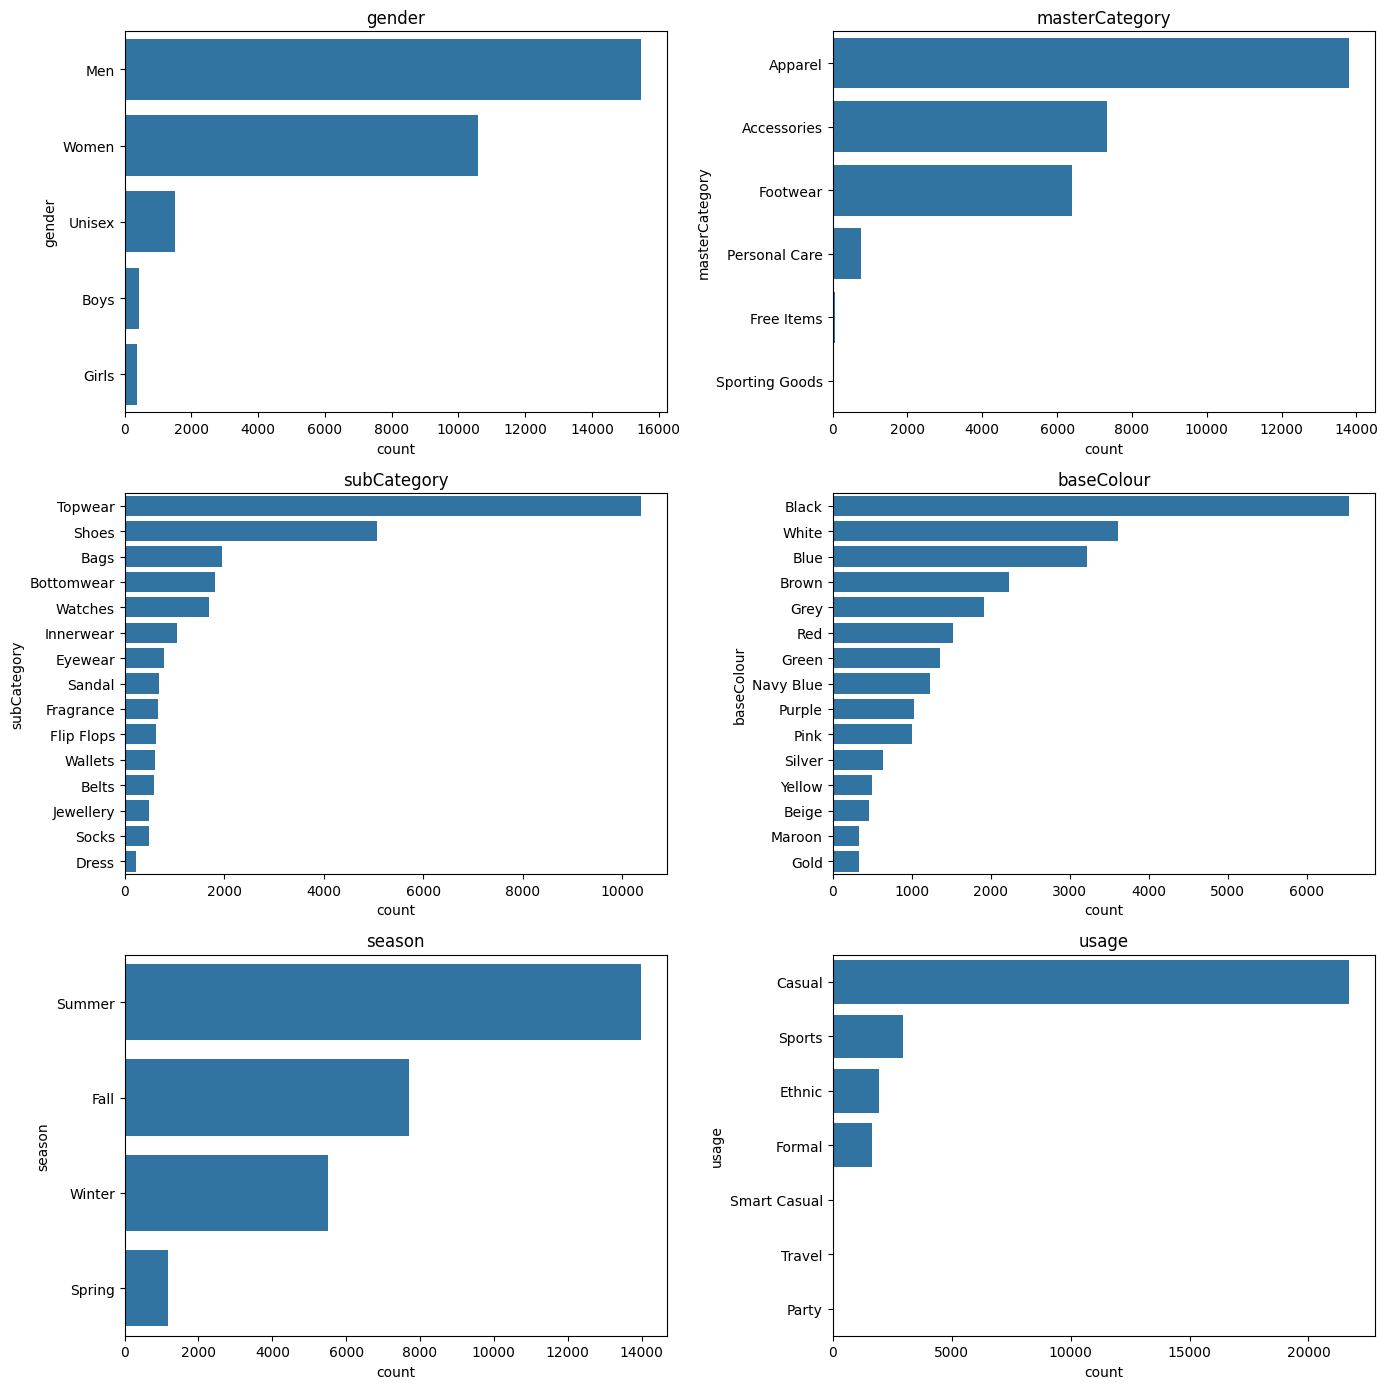

In [20]:
cat_cols = ['gender', 'masterCategory', 'subCategory', 'baseColour', 'season', 'usage']
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for ax, col in zip(axes.flatten(), cat_cols):
    order = train_data[col].value_counts().index[:15]  # top 15 to keep it readable
    sns.countplot(data=train_data, y=col, order=order, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [21]:
print("Category distributions (summary):\n")
for col in cat_cols + ['articleType']:
    vc = train_data[col].value_counts()
    top_val, top_count = vc.index[0], vc.iloc[0]
    top_pct = top_count / len(train_data) * 100
    n_classes = vc.shape[0]
    least_val, least_count = vc.index[-1], vc.iloc[-1]
    print(f"- {col}: {n_classes} categories. "
          f"Most common is '{top_val}' ({top_count} items, {top_pct:.1f}%). "
          f"Least common is '{least_val}' ({least_count} items).")

Category distributions (summary):

- gender: 5 categories. Most common is 'Men' (15476 items, 54.5%). Least common is 'Girls' (356 items).
- masterCategory: 6 categories. Most common is 'Apparel' (13807 items, 48.7%). Least common is 'Sporting Goods' (19 items).
- subCategory: 40 categories. Most common is 'Topwear' (10381 items, 36.6%). Least common is 'Vouchers' (1 items).
- baseColour: 46 categories. Most common is 'Black' (6535 items, 23.0%). Least common is 'Rose' (2 items).
- season: 4 categories. Most common is 'Summer' (13989 items, 49.3%). Least common is 'Spring' (1171 items).
- usage: 7 categories. Most common is 'Casual' (21710 items, 76.5%). Least common is 'Party' (9 items).
- articleType: 121 categories. Most common is 'Tshirts' (4909 items, 17.3%). Least common is 'Rain Trousers' (1 items).


**Result:** `gender` has 5 categories (Men most common at 54.5%, Girls least at 356 items); `masterCategory` has 6 (Apparel most common at 48.7%, Sporting Goods least at 19 items); `subCategory` has 40; `baseColour` has 46 (Black most common at 23.0%, Rose least at 2 items); `season` has 4 (Summer most common at 49.3%); `usage` has 7 categories.

**What this tells us:** several columns have a long tail of small categories -- `articleType` is the most extreme case, worth its own closer look.

**Next:** look specifically at `articleType`, since it has by far the most classes of any target.

### 5.5 The long tail in `articleType` (too many classes for a normal count plot)

**Our approach:** count `articleType`'s classes directly, since a standard bar chart can't legibly show 121 categories at once.

In [22]:
vc = train_data['articleType'].value_counts()
print(f"Distinct articleType classes in train: {train_data['articleType'].nunique()}")
print(f"Classes with fewer than 10 samples: {(vc < 10).sum()}")
print(f"Classes with fewer than 5 samples:  {(vc < 5).sum()}")
vc.head(15)

Distinct articleType classes in train: 121
Classes with fewer than 10 samples: 33
Classes with fewer than 5 samples:  23


articleType
Tshirts         4909
Shirts          2093
Casual Shoes    2034
Watches         1701
Sports Shoes    1498
Kurtas          1189
Tops            1162
Handbags        1070
Sunglasses       789
Heels            774
Sandals          640
Flip Flops       634
Wallets          613
Belts            592
Backpacks        525
Name: count, dtype: int64

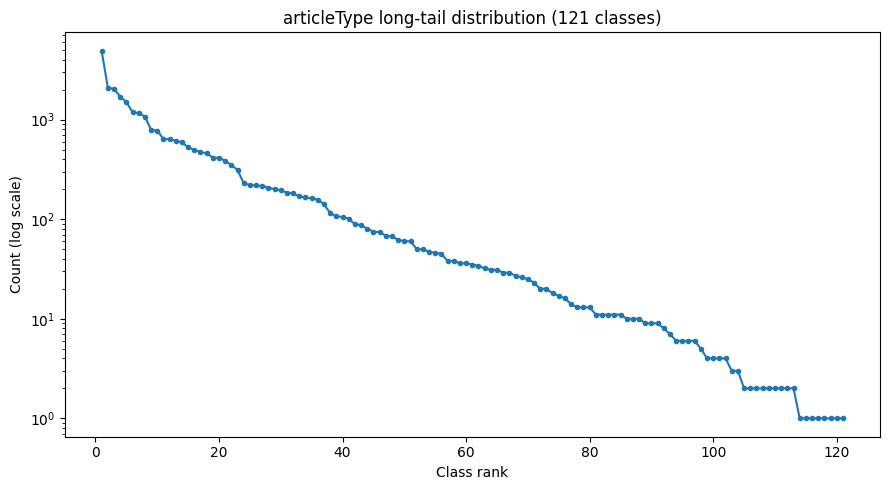

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(vc) + 1), vc.values, marker='o', markersize=3)
ax.set_yscale('log')
ax.set_xlabel('Class rank')
ax.set_ylabel('Count (log scale)')
ax.set_title(f'articleType long-tail distribution ({len(vc)} classes)')
plt.tight_layout()
plt.show()

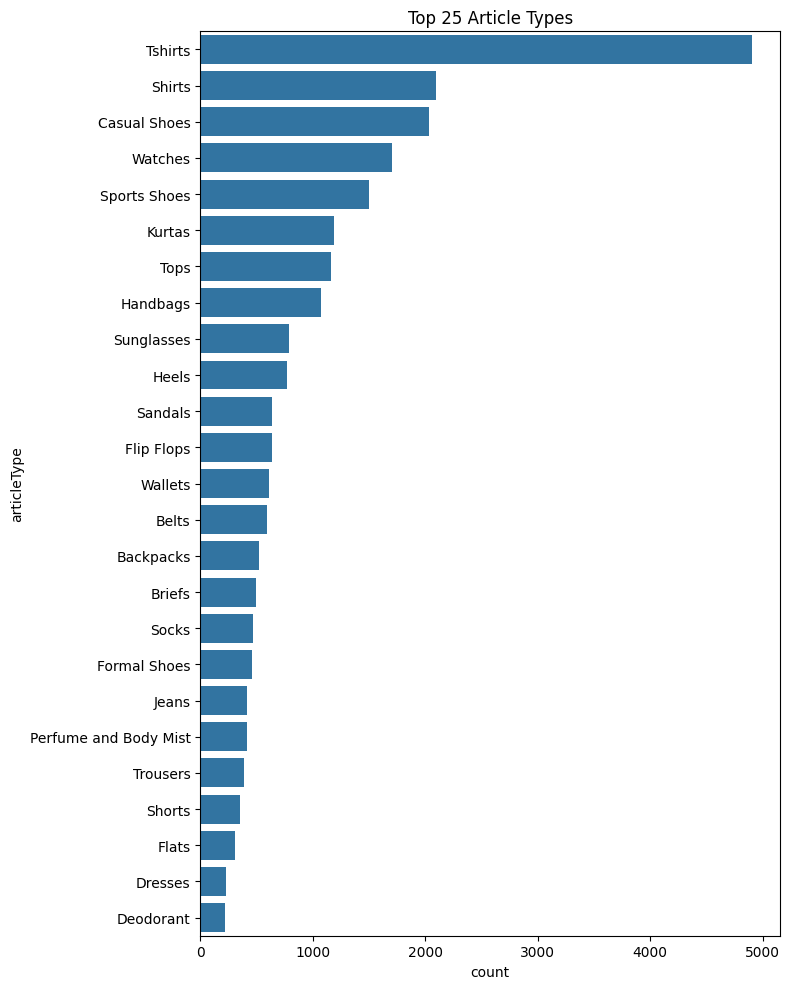

In [24]:
N = 25
plt.figure(figsize=(8, 10))
top_article = train_data['articleType'].value_counts().index[:N]
sns.countplot(data=train_data, y='articleType', order=top_article)
plt.title(f'Top {N} Article Types')
plt.tight_layout()
plt.show()

**Result:** 121 distinct classes in the training data. 33 classes have fewer than 10 samples; 23 have fewer than 5. The most common class (Tshirts, 4,909 rows) is thousands of times larger than the smallest.

**What this tells us:** `articleType` will need rare-class handling before it's usable as a training target -- a class with 1-2 examples genuinely cannot be learned from or fairly evaluated on.

**Next:** check the `year` column for any implausible outlier values.

### 5.6 Year distribution & outliers

**Our approach:** check `year`'s range and look for implausible values using the IQR rule.

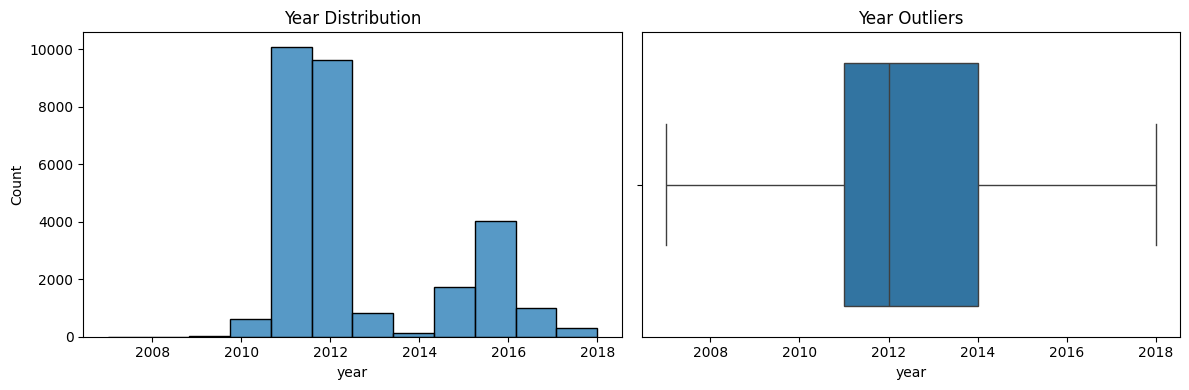

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_data['year'], bins=train_data['year'].nunique(), ax=axes[0])
axes[0].set_title('Year Distribution')
sns.boxplot(x=train_data['year'], ax=axes[1])
axes[1].set_title('Year Outliers')
plt.tight_layout()
plt.show()

In [26]:
year_counts = train_data['year'].value_counts().sort_index()

q1 = train_data['year'].quantile(0.25)
q3 = train_data['year'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_years = train_data[(train_data['year'] < lower_bound) | (train_data['year'] > upper_bound)]['year']
outlier_summary = outlier_years.value_counts().sort_index()

print(f"Data spans {train_data['year'].min():.0f} to {train_data['year'].max():.0f}.")
print(f"Most items are from {year_counts.idxmax():.0f} ({year_counts.max()} items).")
print(f"Outlier years (IQR rule): {outlier_summary.to_dict()}")

Data spans 2007 to 2018.
Most items are from 2011 (10091 items).
Outlier years (IQR rule): {}


**Result:** data spans 2007 to 2018, with 2011 the most common year (10,091 items). No outlier years flagged by the IQR rule.

**What this tells us:** `year` is a clean, well-behaved numeric column -- no cleaning needed before it can be used as a feature.

**Next:** measure how strongly the categorical columns relate to each other.

### 5.7 Cramér's V - how strongly the feature columns are related

**Our approach:** measure the association between categorical columns using Cramér's V, since a very strong relationship between two columns can matter later (e.g. if a feature is almost redundant with a target).

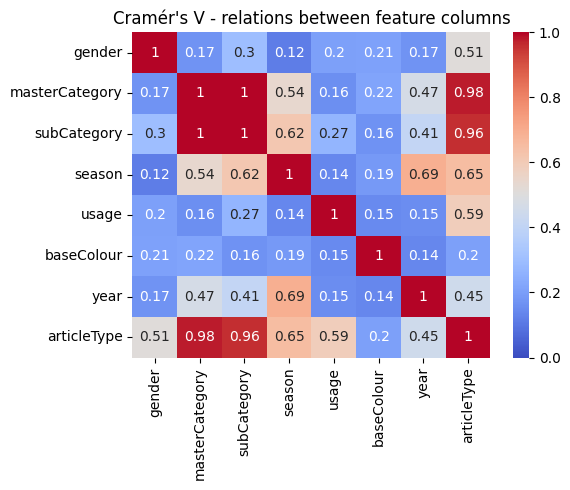

In [27]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

# 'productDisplayName' is deliberately excluded: it is near-unique free text (28,954
# distinct values), so its crosstab is enormous and Cramer's V against it is ~1 by
# construction -- it measures uniqueness, not a real association.
feature_cols = ['gender', 'masterCategory', 'subCategory', 'season',
                'usage', 'baseColour', 'year', 'articleType']
corr_matrix = pd.DataFrame(index=feature_cols, columns=feature_cols, dtype=float)
for c1, c2 in combinations(feature_cols, 2):
    v = cramers_v(train_data[c1], train_data[c2])
    corr_matrix.loc[c1, c2] = v
    corr_matrix.loc[c2, c1] = v
for c in feature_cols:
    corr_matrix.loc[c, c] = 1.0

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix.astype(float), annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Cramér's V - relations between feature columns")
plt.tight_layout()
plt.show()

**Next:** look specifically at how the four target columns relate to each other.

### 5.8 Target distributions & relationships between targets

**Our approach:** look specifically at how `articleType`, `gender`, `season`, and `usage` relate to each other, since these are what the different tasks each predict.

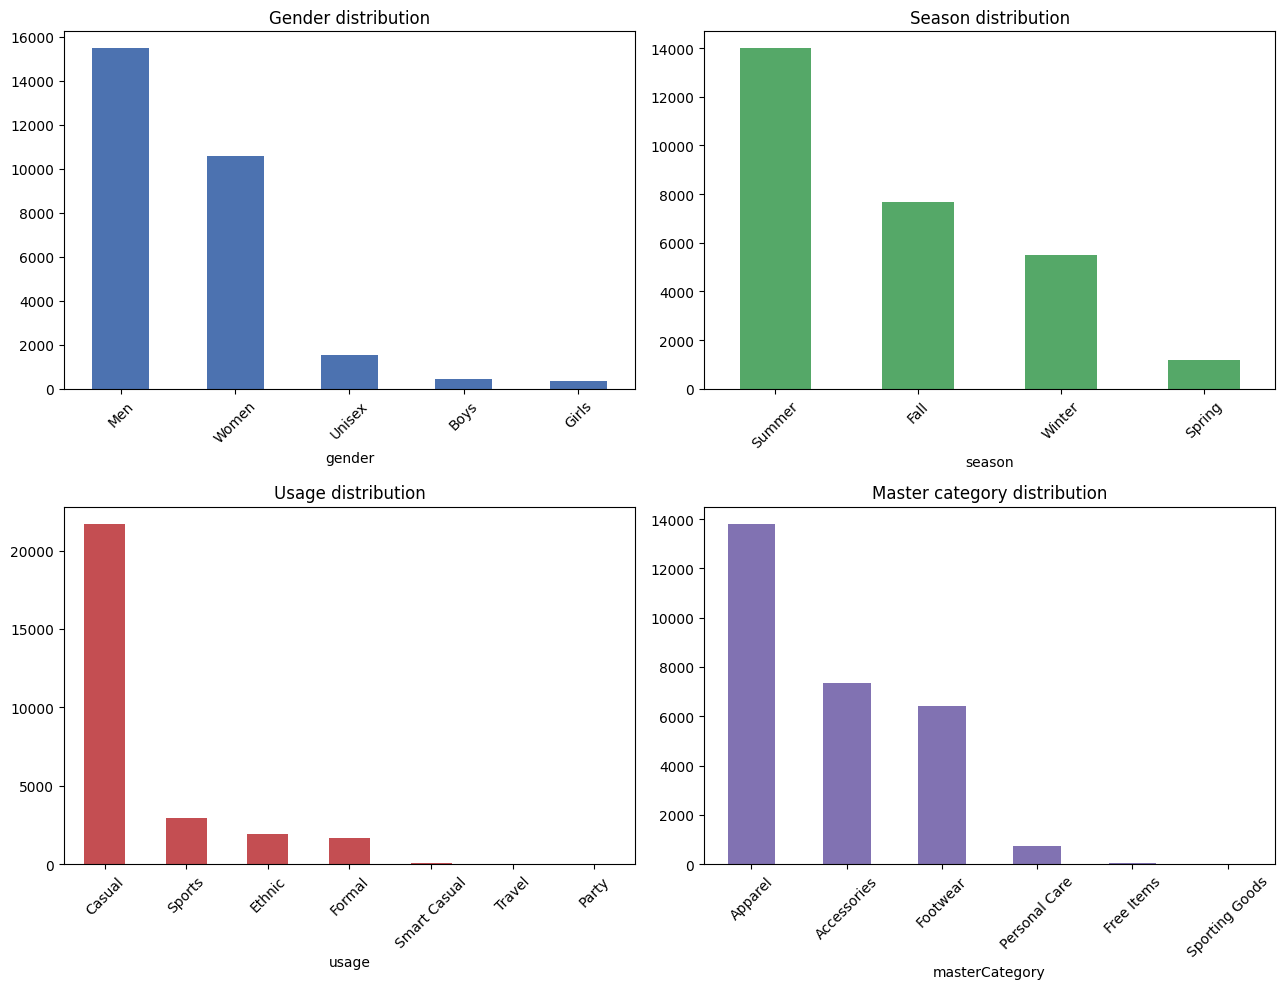

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

train_data['gender'].value_counts().plot(kind='bar', ax=axes[0, 0], color='#4C72B0')
axes[0, 0].set_title('Gender distribution')
axes[0, 0].tick_params(axis='x', rotation=45)

train_data['season'].value_counts().plot(kind='bar', ax=axes[0, 1], color='#55A868')
axes[0, 1].set_title('Season distribution')
axes[0, 1].tick_params(axis='x', rotation=45)

train_data['usage'].value_counts().plot(kind='bar', ax=axes[1, 0], color='#C44E52')
axes[1, 0].set_title('Usage distribution')
axes[1, 0].tick_params(axis='x', rotation=45)

train_data['masterCategory'].value_counts().plot(kind='bar', ax=axes[1, 1], color='#8172B2')
axes[1, 1].set_title('Master category distribution')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

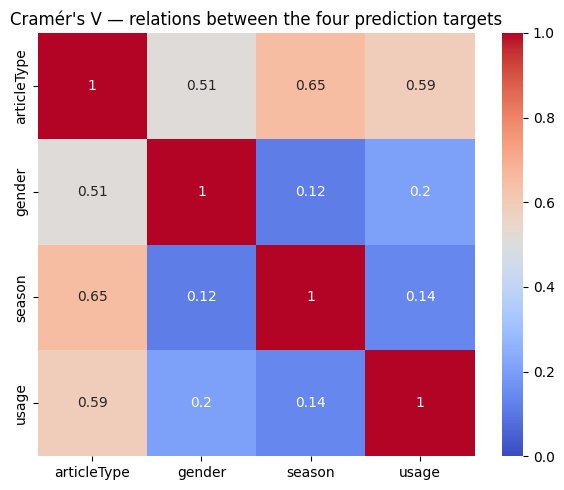

In [29]:
targets = ['articleType', 'gender', 'season', 'usage']

target_corr = pd.DataFrame(index=targets, columns=targets, dtype=float)
for c1, c2 in combinations(targets, 2):
    v = cramers_v(train_data[c1], train_data[c2])
    target_corr.loc[c1, c2] = v
    target_corr.loc[c2, c1] = v
for c in targets:
    target_corr.loc[c, c] = 1.0

plt.figure(figsize=(6, 5))
sns.heatmap(target_corr.astype(float), annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Cramér's V — relations between the four prediction targets")
plt.tight_layout()
plt.show()

Strongest target relationship: articleType vs season (Cramér's V = 0.65)


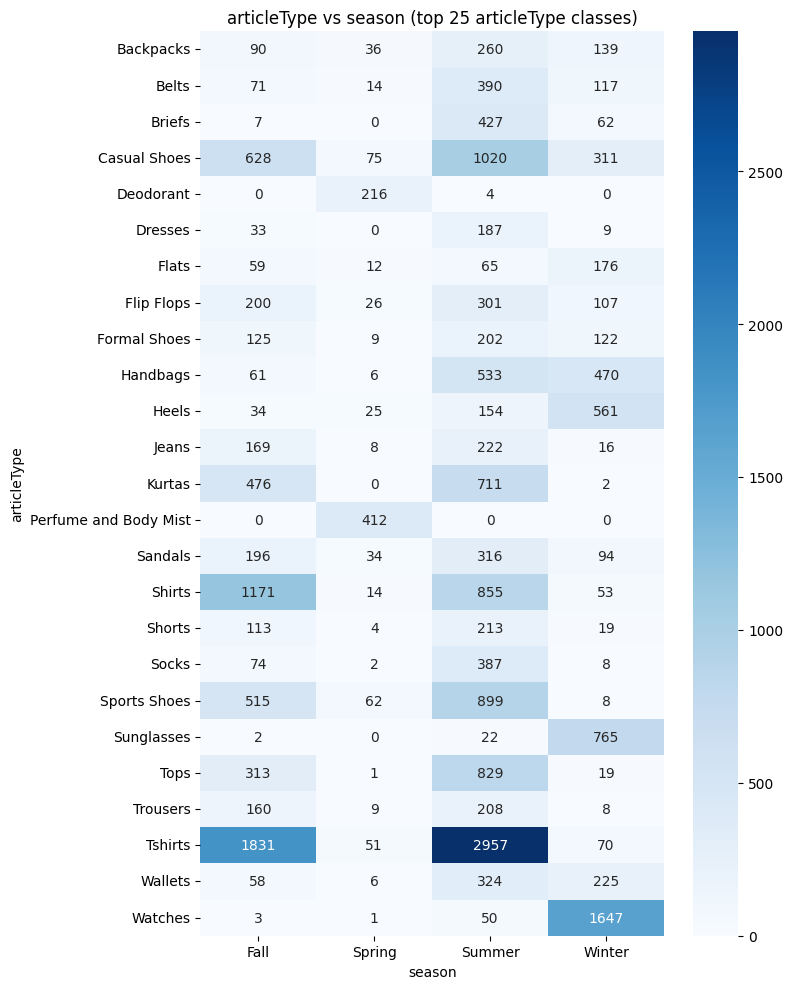

In [30]:
# The strongest target-target relationship, viewed as a crosstab heatmap
strongest_pair = target_corr.where(~np.eye(len(targets), dtype=bool)).stack().idxmax()
c1, c2 = strongest_pair
print(f"Strongest target relationship: {c1} vs {c2} (Cramér's V = {target_corr.loc[c1, c2]:.2f})")

plt.figure(figsize=(8, 10))
ct = pd.crosstab(train_data[c1], train_data[c2])
top_types = train_data[c1].value_counts().index[:25]
sns.heatmap(ct.loc[ct.index.intersection(top_types)], annot=True, fmt='d', cmap='Blues')
plt.title(f'{c1} vs {c2} (top 25 {c1} classes)')
plt.tight_layout()
plt.show()

**Result:** the strongest target-target relationship is `articleType` vs. `season` (Cramér's V = 0.65).

**What this tells us:** an item's category and the season it's meant for are meaningfully linked -- worth keeping in mind if metadata fusion is considered for any task later, since these two targets aren't fully independent signals.

**Next:** quantify exactly how imbalanced each target column is.

### 5.9 How imbalanced are the classes

**Our approach:** compute the imbalance ratio (majority class size / minority class size) directly for each target, rather than relying on visual impressions from the distribution plots.

In [31]:
def imbalance_summary(series, name):
    vc = series.dropna().value_counts()
    ratio = vc.max() / vc.min()
    return {
        'target': name,
        'n_classes': len(vc),
        'majority_class': vc.idxmax(),
        'majority_count': int(vc.max()),
        'minority_class': vc.idxmin(),
        'minority_count': int(vc.min()),
        'imbalance_ratio': round(ratio, 1),
    }

imbalance_table = pd.DataFrame([
    imbalance_summary(train_data['gender'], 'gender'),
    imbalance_summary(train_data['season'], 'season'),
    imbalance_summary(train_data['usage'], 'usage'),
    imbalance_summary(train_data['articleType'], 'articleType'),
])
imbalance_table

,target,n_classes,majority_class,majority_count,minority_class,minority_count,imbalance_ratio
0,gender,5,Men,15476,Girls,356,43.5
1,season,4,Summer,13989,Spring,1171,11.9
2,usage,7,Casual,21710,Party,9,2412.2
3,articleType,121,Tshirts,4909,Hat,1,4909.0


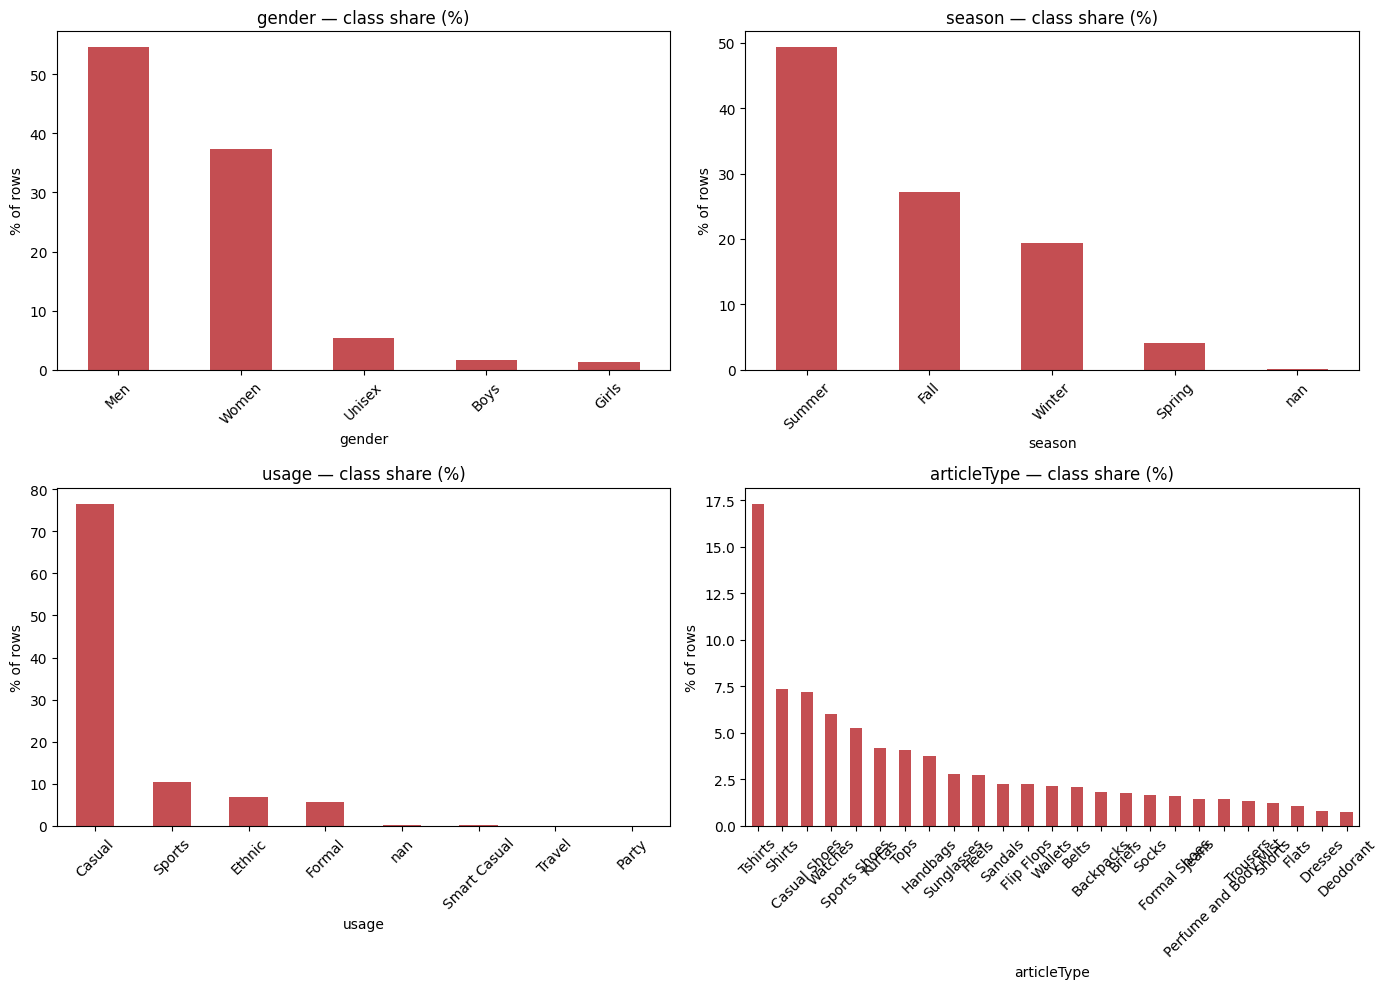

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), ['gender', 'season', 'usage', 'articleType']):
    shares = train_data[col].value_counts(normalize=True, dropna=False) * 100
    if col == 'articleType':
        shares = shares.head(25)
    shares.plot(kind='bar', ax=ax, color='#C44E52')
    ax.set_ylabel('% of rows')
    ax.set_title(f'{col} — class share (%)')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Result:** `gender` imbalance ratio 43.5 (Men 15,476 vs. Girls 356); `season` 11.9 (Summer 13,989 vs. Spring 1,171); `usage` 2,412.2 (Casual 21,710 vs. Party 9); `articleType` 4,909.0 (Tshirts 4,909 vs. Hat 1).

**What this tells us:** `usage` and `articleType` are severely imbalanced -- both will need rare-class handling; `gender` and `season` are imbalanced but every class still has thousands of examples, so they can be used as-is without merging categories.

**Next:** check the images themselves -- size, colour mode, file size.

### 5.10 Checking the images: size, color mode, file size (train data only)

**Our approach:** check pixel dimensions, colour mode, and file size for the training images specifically, since these directly determine what the preprocessing pipeline needs to handle.

In [33]:
def profile_images(ids, folder):
    rows = []
    for img_id in ids:
        p = folder / f"{img_id}.jpg"
        try:
            with Image.open(p) as im:      # reads header only, fast
                w, h, mode = im.size[0], im.size[1], im.mode
        except Exception:
            w = h = None
            mode = "ERR"
        rows.append({"id": img_id, "w": w, "h": h, "mode": mode,
                     "kb": round(p.stat().st_size / 1024, 2)})
    return pd.DataFrame(rows)

imgs_train = profile_images(train_data['id'], IMAGES_TRAIN_DIR)
print("Most common dimensions (train):")
print(imgs_train.groupby(['w', 'h']).size().sort_values(ascending=False).head())
print("\nColour mode counts (train):", imgs_train['mode'].value_counts().to_dict())

Most common dimensions (train):
w   h 
60  80    28361
53  80        4
60  60        3
    77        2
    75        1
dtype: int64

Colour mode counts (train): {'RGB': 28113, 'L': 258}


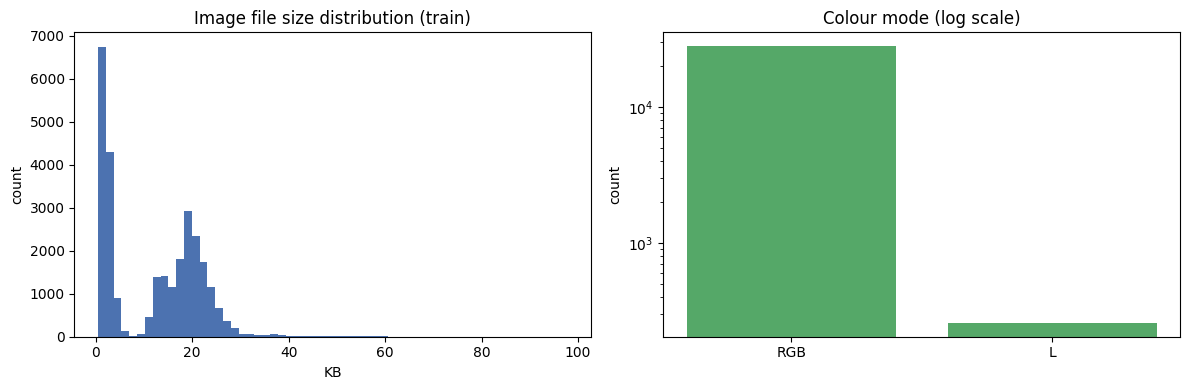

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(imgs_train["kb"], bins=60, color="#4C72B0")
ax[0].set(title="Image file size distribution (train)", xlabel="KB", ylabel="count")

mode_counts = imgs_train["mode"].value_counts()
ax[1].bar(mode_counts.index.astype(str), mode_counts.values, color="#55A868")
ax[1].set_yscale("log")
ax[1].set(title="Colour mode (log scale)", ylabel="count")
plt.tight_layout()
plt.show()

**Result:** images are almost all a consistent 60x80 pixels (28,361 of them), with a handful of size outliers. 258 images are grayscale (`L` mode) rather than colour (28,113 are RGB) -- these need converting to RGB before going into a CNN. File sizes are mostly small, and none failed the integrity check earlier.

**Next:** with the raw data fully explored and understood, build the concrete preprocessing pipeline that every downstream task will load and reuse.

## 6. Processing the Data

**Our approach:** turn the findings above into a concrete, reproducible pipeline: clean the raw data, decide how to handle missing values and rare classes per task, encode labels, prepare images -- then save everything to disk so downstream notebooks load a trustworthy, consistent starting point.

### 6.1 Basic cleaning

**Our approach:** apply the cleaning identified above -- dropping the malformed columns, unmatched rows, and conflicting/duplicate image rows -- as one reusable function.

In [35]:
def clean_dataframe(data):
    """Whitespace-strip categorical/text columns, coerce year to numeric,
    and fill non-target missing values with a placeholder. Fit-free — safe
    to reuse on train, val, or a future test split."""
    data = data.copy()

    # Note: 'articleType_grouped' isn't in this list -- it doesn't exist yet at this point
    # in the pipeline (created in Section 6.3, after cleaning), and it derives from
    # already-cleaned 'articleType'/'subCategory' values, so it needs no separate stripping.
    cat_cols = ['gender', 'masterCategory', 'subCategory', 'articleType',
                'baseColour', 'season', 'usage', 'productDisplayName']
    for c in cat_cols:
        if c in data.columns:
            data[c] = data[c].astype('string').str.strip()

    if 'year' in data.columns:
        data['year'] = pd.to_numeric(data['year'], errors='coerce')

    # baseColour / productDisplayName aren't prediction targets, so missing values
    # here don't block any task — fill rather than drop.
    for c in ['baseColour', 'productDisplayName']:
        if c in data.columns:
            data[c] = data[c].fillna('Unknown')

    return data

train_data = clean_dataframe(train_data)
val_data = clean_dataframe(val_data)

print("Missing values after cleaning (train):")
print(train_data.isnull().sum())
print("\nMissing values after cleaning (val):")
print(val_data.isnull().sum())

Missing values after cleaning (train):
id                     0
gender                 0
masterCategory         0
subCategory            0
articleType            0
baseColour             0
season                14
year                   0
usage                 56
productDisplayName     0
dup_group              0
dtype: int64

Missing values after cleaning (val):
id                     0
gender                 0
masterCategory         0
subCategory            0
articleType            0
baseColour             0
season                 6
year                   0
usage                 15
productDisplayName     0
dup_group              0
dtype: int64


**Next:** decide, per task, how to handle rows with a missing target value.

### 6.2 What to do about missing values, per task

**Our approach:** for each of the four target columns, decide directly whether to impute a missing value or drop the row, based on how many rows are actually affected and whether a safe default exists.

**Next:** decide how to handle classes that are too rare to reasonably learn from.

### 6.3 Handling rare classes, per task

**Our approach:** for `articleType` and `usage` -- the two severely imbalanced targets found in Section 5.9 -- decide how to fold or group classes too rare to learn from reliably.

In [36]:
vc_article = train_data['articleType'].value_counts()
print(f"Total articleType classes (train): {len(vc_article)}")
print(f"Classes with fewer than 10 samples: {(vc_article < 10).sum()}")
print(f"Classes with fewer than 5 samples:  {(vc_article < 5).sum()}\n")

for thresh in [5, 10, 15, 20, 30, 50]:
    kept_classes = (vc_article >= thresh).sum()
    kept_rows = vc_article[vc_article >= thresh].sum()
    print(f"threshold={thresh:>3}: classes kept={kept_classes:>3}/{len(vc_article)}, "
          f"rows kept={kept_rows:>6} ({kept_rows/len(train_data)*100:.1f}% of train)")

Total articleType classes (train): 121
Classes with fewer than 10 samples: 33
Classes with fewer than 5 samples:  23

threshold=  5: classes kept= 98/121, rows kept= 28323 (99.8% of train)
threshold= 10: classes kept= 88/121, rows kept= 28252 (99.6% of train)
threshold= 15: classes kept= 76/121, rows kept= 28114 (99.1% of train)
threshold= 20: classes kept= 73/121, rows kept= 28063 (98.9% of train)
threshold= 30: classes kept= 65/121, rows kept= 27864 (98.2% of train)
threshold= 50: classes kept= 53/121, rows kept= 27415 (96.6% of train)


In [37]:
ARTICLE_TYPE_MIN_COUNT = 20  # keeps most classes while dropping the near-unlearnable long tail

rare_article_types = set(vc_article[vc_article < ARTICLE_TYPE_MIN_COUNT].index)

def apply_article_type_grouping(data, rare_set):
    """Redistributes rare articleType rows into their own subCategory, rather than a
    single 'Other' bucket. `rare_set` is fixed from train-only counts and applied as-is
    to both splits -- never recomputed from val."""
    data = data.copy()
    rare_mask = data['articleType'].isin(rare_set)
    data['articleType_grouped'] = data['articleType']
    data.loc[rare_mask, 'articleType_grouped'] = data.loc[rare_mask, 'subCategory']
    return data

train_data = apply_article_type_grouping(train_data, rare_article_types)
val_data = apply_article_type_grouping(val_data, rare_article_types)

print(f"Rare articleType classes folded into subCategory: {len(rare_article_types)}")
print("Classes after grouping (train):", train_data['articleType_grouped'].nunique())
print("\nRare rows redistributed into (train):")
print(train_data.loc[train_data['articleType'].isin(rare_article_types), 'articleType_grouped'].value_counts())

Rare articleType classes folded into subCategory: 48
Classes after grouping (train): 95

Rare rows redistributed into (train):
articleType_grouped
Bottomwear                  38
Topwear                     34
Lips                        28
Bags                        25
Makeup                      25
Shoe Accessories            18
Accessories                 16
Nails                       16
Sports Equipment            15
Innerwear                   15
Gloves                      14
Socks                       11
Dress                       10
Eyes                         9
Apparel Set                  8
Water Bottle                 7
Wristbands                   4
Umbrellas                    4
Headwear                     3
Loungewear and Nightwear     3
Sports Accessories           2
Cufflinks                    1
Bath and Body                1
Vouchers                     1
Name: count, dtype: Int64


In [38]:
# Verify the redistribution actually fixed the imbalance -- if a subCategory a rare
# articleType got folded into is itself still small, the long tail has moved, not gone.
post_counts = train_data['articleType_grouped'].value_counts()
still_rare = post_counts[post_counts < ARTICLE_TYPE_MIN_COUNT]
print(f"articleType_grouped classes still below {ARTICLE_TYPE_MIN_COUNT} samples after redistribution: {len(still_rare)}")
if len(still_rare):
    print(still_rare)

articleType_grouped classes still below 20 samples after redistribution: 17
articleType_grouped
Shoe Accessories            18
Accessories                 16
Nails                       16
Sports Equipment            15
Innerwear                   15
Gloves                      14
Dress                       10
Eyes                         9
Apparel Set                  8
Water Bottle                 7
Wristbands                   4
Umbrellas                    4
Headwear                     3
Loungewear and Nightwear     3
Sports Accessories           2
Bath and Body                1
Vouchers                     1
Name: count, dtype: Int64


**Result:** rare `articleType` classes below the chosen threshold are folded into their parent `subCategory`, reducing the number of unusable near-empty classes while keeping the categories that matter distinct.

**Next:** apply the same kind of decision to `usage`, which has no parent column to fold into.

In [39]:
USAGE_MIN_COUNT = 100

vc_usage = train_data['usage'].value_counts()
for thresh in [10, 25, 50, 100, 150]:
    kept_classes = (vc_usage >= thresh).sum()
    kept_rows = vc_usage[vc_usage >= thresh].sum()
    print(f"threshold={thresh:>3}: classes kept={kept_classes}/{len(vc_usage)}, "
          f"rows kept={kept_rows} ({kept_rows/train_data['usage'].notna().sum()*100:.1f}% of usage rows)")

threshold= 10: classes kept=6/7, rows kept=28306 (100.0% of usage rows)
threshold= 25: classes kept=5/7, rows kept=28287 (99.9% of usage rows)
threshold= 50: classes kept=4/7, rows kept=28244 (99.7% of usage rows)
threshold=100: classes kept=4/7, rows kept=28244 (99.7% of usage rows)
threshold=150: classes kept=4/7, rows kept=28244 (99.7% of usage rows)


In [40]:
rare_usage = vc_usage[vc_usage < USAGE_MIN_COUNT].index

for d in (train_data, val_data):
    d['usage_grouped'] = d['usage'].where(~d['usage'].isin(rare_usage), 'Other')

print("usage classes after grouping (train):", train_data['usage_grouped'].nunique())
print(train_data['usage_grouped'].value_counts())

usage classes after grouping (train): 5
usage_grouped
Casual    21710
Sports     2942
Ethnic     1953
Formal     1639
Other        71
Name: count, dtype: Int64


**Removing duplicates now, before the split.** `usage` doesn't have a parent column to redistribute into, so rare classes here go into a single `Other` bucket instead. The classes folded in account for a small number of rows, so `Other` stays small enough not to distort the remaining four classes. Same train-only approach as `articleType`.

**Next:** decide whether `gender` and `season` need the same treatment.

**`gender`** and **`season`** don't need any merging. `gender` has 5 classes and `season` has 4 -- both imbalanced (Section 5.9), but every class still has enough samples to split, encode, and learn from without needing to combine categories.

**Next:** build one dataset per task, using each task's (possibly grouped) target column.

### 6.4 Dataset split for each task

**Our approach:** it would be easy to assume a `masterCategory`-stratified split doesn't balance `season` well enough, and draw a second, season-stratified split just for Task 2. That has a real cost: with two splits, a row can be training data for one task and validation data for another. So this section measures the assumption instead of acting on it -- the pipeline uses one split for all four tasks, and the numbers here are the evidence for why a second split isn't needed.

The cell below builds candidate stratification keys of increasing granularity and reports the worst-case train-vs-validation gap for every target class, in percentage points. This cell only measures -- it does not change the split the rest of the notebook exports.

In [41]:
# Column actually used as the prediction target for each task
target_columns = {
    'articleType': 'articleType_grouped',
    'season': 'season',
    'gender': 'gender',
    'usage': 'usage_grouped',
}

def usable_subset(data, target_col):
    return data[data[target_col].notna()].reset_index(drop=True)

train_usable = {t: usable_subset(train_data, col) for t, col in target_columns.items()}
val_usable = {t: usable_subset(val_data, col) for t, col in target_columns.items()}

for t in target_columns:
    print(f"{t}: train usable={len(train_usable[t])}, val usable={len(val_usable[t])}")


# Diagnostic only -- computes no split that is used downstream.
def build_stratify_key(frame, cols, min_stratum=4):
    """Composite stratification key. Rare combinations back off to a coarser key
    instead of being dropped, so every row keeps a stratum."""
    key = frame[cols].fillna('NA').astype(str).agg('|'.join, axis=1)
    for level in range(len(cols) - 1, 0, -1):
        vc = key.value_counts()
        rare = set(vc[vc < min_stratum].index)
        if not rare:
            break
        coarse = frame[cols[:level]].fillna('NA').astype(str).agg('|'.join, axis=1) + f'|<L{level}>'
        key = key.where(~key.isin(rare), coarse)
    # Final catch-all. Note a plain '<rare>' bucket is not enough: if only two rows remain
    # rare, that bucket is itself below min_stratum and StratifiedGroupKFold warns and
    # places them arbitrarily. Merge the stragglers into the largest existing stratum,
    # which is guaranteed big enough to absorb them.
    vc = key.value_counts()
    rare = set(vc[vc < min_stratum].index)
    if rare:
        largest = vc.idxmax()
        key = key.where(~key.isin(rare), largest)
    assert key.value_counts().min() >= min_stratum, "a stratum is still below min_stratum"
    return key


def split_balance(frame, key, targets):
    """Worst-case train-vs-val gap (percentage points) for each target column."""
    sgkf_probe = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
    tr_idx, va_idx = next(sgkf_probe.split(frame, key, groups=frame['dup_group']))
    tr, va = frame.iloc[tr_idx], frame.iloc[va_idx]
    assert not set(tr['dup_group']) & set(va['dup_group']), "duplicate group spans the split"
    out = {}
    for t in targets:
        a = tr[t].value_counts(normalize=True, dropna=False)
        b = va[t].value_counts(normalize=True, dropna=False)
        out[t] = round(a.sub(b, fill_value=0).abs().max() * 100, 3)
    return out


# Raw `usage`, not `usage_grouped`: the grouped column is derived from train-only counts
# AFTER the split, so using it to build the split would be circular.
TARGETS = ['masterCategory', 'season', 'gender', 'usage']
CANDIDATE_KEYS = {
    'masterCategory only (current)':      ['masterCategory'],
    'season only (Task 2 split)':         ['season'],
    'masterCategory x season':            ['masterCategory', 'season'],
    'masterCategory x season x gender':   ['masterCategory', 'season', 'gender'],
    'all four (composite)':               ['masterCategory', 'season', 'gender', 'usage'],
}

rows = []
for label, cols in CANDIDATE_KEYS.items():
    key = build_stratify_key(df, cols)
    row = {'stratify_on': label, 'n_strata': int(key.nunique()),
           'backed_off_rows': int(key.str.contains('<', regex=False).sum())}
    row.update(split_balance(df, key, TARGETS))
    rows.append(row)

strat_comparison = pd.DataFrame(rows).set_index('stratify_on')
print("Worst-case train-vs-val gap per target column, in percentage points")
print("(lower is better; 0 = distribution preserved exactly)\n")
display(strat_comparison)

current = strat_comparison.loc['masterCategory only (current)']
best = strat_comparison.loc['all four (composite)']
print(f"Season gap under the current masterCategory split : {current['season']:.3f} pp")
print(f"Season gap under a composite key                  : {best['season']:.3f} pp")
print(f"Gender gap under the current masterCategory split  : {current['gender']:.3f} pp")
print(f"Gender gap under a composite key                   : {best['gender']:.3f} pp")
print(f"Usage gap under the current masterCategory split   : {current['usage']:.3f} pp")
print(f"Usage gap under a composite key                    : {best['usage']:.3f} pp")
print(f"Worst gap across ALL four targets, composite key   : {best[TARGETS].max():.3f} pp")
print(f"Rows lost to fragmentation with the composite key  : 0 "
      f"({int(best['backed_off_rows'])} rows sit in a backed-off stratum)")

articleType: train usable=28371, val usable=9457
season: train usable=28357, val usable=9451
gender: train usable=28371, val usable=9457
usage: train usable=28315, val usable=9442
Worst-case train-vs-val gap per target column, in percentage points
(lower is better; 0 = distribution preserved exactly)



,n_strata,backed_off_rows,masterCategory,season,gender,usage
stratify_on,,,,,,
masterCategory only (current),6,0,0.011,0.035,0.620,0.423
season only (Task 2 split),5,0,0.303,0.007,0.522,0.180
masterCategory x season,19,0,0.021,0.021,0.300,0.254
masterCategory x season x gender,64,9,0.025,0.035,0.028,0.832
all four (composite),152,66,0.038,0.053,0.078,0.039


Season gap under the current masterCategory split : 0.035 pp
Season gap under a composite key                  : 0.053 pp
Gender gap under the current masterCategory split  : 0.620 pp
Gender gap under a composite key                   : 0.078 pp
Usage gap under the current masterCategory split   : 0.423 pp
Usage gap under a composite key                    : 0.039 pp
Worst gap across ALL four targets, composite key   : 0.078 pp
Rows lost to fragmentation with the composite key  : 0 (66 rows sit in a backed-off stratum)


**Next:** with the split decision confirmed by evidence, turn the text labels into numbers a model can train on.

### 6.5 Turning labels into numbers

**Our approach:** fit a `LabelEncoder` per target column, on the training data only, and save the fitted encoders so every downstream notebook decodes predictions the same way.

In [42]:
encoders = {}
label_maps = {}

for t, col in target_columns.items():
    le = LabelEncoder()
    le.fit(train_usable[t][col])
    encoders[t] = le
    label_maps[t] = {i: c for i, c in enumerate(le.classes_)}

    train_usable[t][col + '_enc'] = le.transform(train_usable[t][col])

    val_known = val_usable[t][val_usable[t][col].isin(le.classes_)]
    dropped = len(val_usable[t]) - len(val_known)
    if dropped:
        print(f"WARNING: dropped {dropped} val rows for '{t}' — label(s) not seen in train")
    val_usable[t] = val_known.reset_index(drop=True)
    val_usable[t][col + '_enc'] = le.transform(val_usable[t][col])

    print(f"{t}: {len(le.classes_)} classes" + (f" -> {label_maps[t]}" if len(le.classes_) <= 6 else ""))

articleType: 95 classes
season: 4 classes -> {0: 'Fall', 1: 'Spring', 2: 'Summer', 3: 'Winter'}
gender: 5 classes -> {0: 'Boys', 1: 'Girls', 2: 'Men', 3: 'Unisex', 4: 'Women'}
usage: 5 classes -> {0: 'Casual', 1: 'Ethnic', 2: 'Formal', 3: 'Other', 4: 'Sports'}


**Next:** build the tools needed to fix each task's class imbalance during training.

### 6.6 Fixing class imbalance

**Our approach:** build a `WeightedRandomSampler` per task, so training naturally oversamples rare categories rather than needing the loss function itself to compensate.

In [43]:
# Reference-only class weights (not used in the training loss)
class_weights = {}
for t, col in target_columns.items():
    data = train_usable[t]
    vc = data[col].value_counts().sort_index()
    n_classes, n_samples = len(vc), len(data)
    weights = n_samples / (n_classes * vc)
    weights = weights / weights.mean()
    ordered = [weights[c] for c in encoders[t].classes_]
    class_weights[t] = np.array(ordered)
    print(f"{t}: weight range {class_weights[t].min():.2f}-{class_weights[t].max():.2f}")

articleType: weight range 0.00-16.71
season: weight range 0.23-2.76
gender: weight range 0.05-2.39
usage: weight range 0.01-4.52


In [44]:
def get_weighted_sampler(data, target_col):
    """WeightedRandomSampler that oversamples minority classes within `data`.
    Call on the training subset only."""
    class_counts = data[target_col].value_counts()
    inv_freq = {cls: 1.0 / count for cls, count in class_counts.items()}
    sample_weights = torch.tensor(data[target_col].map(inv_freq).values, dtype=torch.float32)
    return WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

samplers = {}
for t, col in target_columns.items():
    samplers[t] = get_weighted_sampler(train_usable[t], col)
    print(f"{t}: sampler built on {len(train_usable[t])} training rows")

articleType: sampler built on 28371 training rows
season: sampler built on 28357 training rows
gender: sampler built on 28371 training rows
usage: sampler built on 28315 training rows


**Next:** fix the image size and normalization statistics every model will use.

### 6.7 Image size and normalization

**Our approach:** fix a single target image size and compute normalization statistics from the training images, so every model in every task uses identical preprocessing.

In [45]:
IMG_WIDTH, IMG_HEIGHT = 60, 80

sample_ids = train_data['id'].sample(min(3000, len(train_data)), random_state=RANDOM_STATE)

pixel_sum = np.zeros(3)
pixel_sq_sum = np.zeros(3)
n_pixels = 0

for img_id in sample_ids:
    img = Image.open(IMAGES_TRAIN_DIR / f"{img_id}.jpg").convert("RGB")
    arr = np.asarray(img, dtype=np.float64) / 255.0
    pixel_sum += arr.sum(axis=(0, 1))
    pixel_sq_sum += (arr ** 2).sum(axis=(0, 1))
    n_pixels += arr.shape[0] * arr.shape[1]

mean = pixel_sum / n_pixels
std = np.sqrt(pixel_sq_sum / n_pixels - mean ** 2)

print(f"Computed mean (RGB): {mean.round(4)}")
print(f"Computed std (RGB):  {std.round(4)}")

Computed mean (RGB): [0.8476 0.8307 0.8243]
Computed std (RGB):  [0.274  0.285  0.2889]


**Next:** build the actual training/evaluation transform pipelines.

### 6.8 Transform pipelines

**Our approach:** build separate training and evaluation transform pipelines -- light, realistic augmentation for training; no augmentation for evaluation, so validation stays a faithful, unaltered test.

In [46]:
# Base/eval pipeline — used for validation, test, and as the foundation of the
# training pipeline. Never augmented, so it stays a faithful evaluation signal.
base_transform = T.Compose([
    T.Lambda(lambda img: img.convert("RGB")),   # handles the grayscale files found in Section 5.10
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])
eval_transform = base_transform

# Training pipeline — adds mild, conservative augmentation. Kept conservative because
# these are catalog product photos, not natural scenes: a vertical flip or a large
# rotation would produce an unrealistic example (e.g. an upside-down shoe).
train_transform = T.Compose([
    T.Lambda(lambda img: img.convert("RGB")),
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])

print("Transforms ready: base_transform / eval_transform (no augmentation), train_transform (augmented)")

Transforms ready: base_transform / eval_transform (no augmentation), train_transform (augmented)


Augmentation isn't targeted at rare classes specifically -- it just naturally works well with the sampler from Section 6.6. Since rare-class images get picked more often by the sampler, they also get augmented more often, which is exactly the extra variety they need.

**Next:** wrap the images and labels into a PyTorch `Dataset` class every task can reuse.

### 6.9 Wrapping everything in a PyTorch Dataset

**Our approach:** define one `Dataset` class that opens an image, applies the given transform, and returns it with its encoded label -- shared by every task rather than redefined per notebook.

In [47]:
class FashionImageDataset(Dataset):
    """Wraps a per-task dataframe (from train_usable / val_usable) with its images
    and label encoder. Pass `train_transform` for training data, `eval_transform`
    for validation/test data."""

    def __init__(self, dataframe, images_dir, target_col_enc, transform):
        self.df = dataframe.reset_index(drop=True)
        self.images_dir = images_dir
        self.target_col_enc = target_col_enc
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(self.images_dir / f"{row['id']}.jpg") as im:
            img = self.transform(im)
        label = int(row[self.target_col_enc])
        return img, torch.tensor(label, dtype=torch.long)


# Example: build the four training datasets (validation datasets follow the same pattern
# with eval_transform and no sampler)
task_datasets = {
    t: FashionImageDataset(train_usable[t], IMAGES_TRAIN_DIR, col + '_enc', train_transform)
    for t, col in target_columns.items()
}
for t, ds in task_datasets.items():
    print(f"{t}: {len(ds)} training images")

articleType: 28371 training images
season: 28357 training images
gender: 28371 training images
usage: 28315 training images


**Next:** save every configuration decision made above into one file.

### 6.10 Saving all our settings in one file

**Our approach:** write every configuration value decided above (image size, normalization stats, rare-class thresholds, random seed, split method) into a single config file, so every downstream notebook reads the exact same settings instead of risking silent drift between notebooks.

In [48]:
config = {
    "random_state": RANDOM_STATE,
    "split": {
        "method": "single_stratified_group_holdout",
        "splitter": "StratifiedGroupKFold(n_splits=4), first split only",
        "validation_fraction": 0.25,
        "stratify_on": "masterCategory",  # deliberately not articleType -- see Section 4
        "group_on": "dup_group (exact-duplicate images)",
    },
    "image": {
        "width": IMG_WIDTH,
        "height": IMG_HEIGHT,
        "normalization_mean": mean.tolist(),
        "normalization_std": std.tolist(),
    },
    "rare_class_thresholds": {
        "articleType": ARTICLE_TYPE_MIN_COUNT,
        "usage": USAGE_MIN_COUNT,
    },
    "rare_class_handling": {
        "articleType": "redistributed into subCategory (train-only counts + val-only-class check)",
        "usage": "redistributed into 'Other' (no parent column to redistribute into)",
    },
    "class_counts": {t: int(len(encoders[t].classes_)) for t in target_columns},
    "imbalance_handling": "WeightedRandomSampler (train only) + augmentation; no loss-level class weighting",
    "missing_images_dropped": missing_images,
    "duplicate_image_pairs_found": len(df) - df['dup_group'].nunique(),
    "eda_scope": "train_data only, post-split, per course instruction",
}

with open(OUT_DIR / 'pipeline_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(json.dumps(config, indent=2))

{
  "random_state": 42,
  "split": {
    "method": "single_stratified_group_holdout",
    "splitter": "StratifiedGroupKFold(n_splits=4), first split only",
    "validation_fraction": 0.25,
    "stratify_on": "masterCategory",
    "group_on": "dup_group (exact-duplicate images)"
  },
  "image": {
    "width": 60,
    "height": 80,
    "normalization_mean": [
      0.8476490582788704,
      0.8306989185729852,
      0.8242569716775607
    ],
    "normalization_std": [
      0.273956261968577,
      0.2850324570903301,
      0.2889062535778489
    ]
  },
  "rare_class_thresholds": {
    "articleType": 20,
    "usage": 100
  },
  "rare_class_handling": {
    "articleType": "redistributed into subCategory (train-only counts + val-only-class check)",
    "usage": "redistributed into 'Other' (no parent column to redistribute into)"
  },
  "class_counts": {
    "articleType": 95,
    "season": 4,
    "gender": 5,
    "usage": 5
  },
  "imbalance_handling": "WeightedRandomSampler (train only) +

**Next:** save the actual processed data files themselves.

### 6.11 Saving the processed files

**Our approach:** write the cleaned full split and each task's usable subset to disk, so downstream notebooks load directly rather than repeating any of this pipeline.

In [49]:
export_dir = OUT_DIR / 'holdout_metadata'
export_dir.mkdir(parents=True, exist_ok=True)

for t in target_columns:
    train_usable[t].to_csv(export_dir / f'{t}_train.csv', index=False)
    val_usable[t].to_csv(export_dir / f'{t}_val.csv', index=False)
    print(f"{t}: exported {len(train_usable[t])} train and {len(val_usable[t])} validation rows")

with open(OUT_DIR / 'label_encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

mapping_dir = export_dir / 'label_mappings'
mapping_dir.mkdir(exist_ok=True)
for t, encoder in encoders.items():
    (mapping_dir / f'{t}.json').write_text(
        json.dumps({str(i): label for i, label in enumerate(encoder.classes_)}, indent=2),
        encoding='utf-8',
    )

# Full cleaned train/val (all columns, all rows) kept for reference
train_data.to_csv(OUT_DIR / 'train_full.csv', index=False)
val_data.to_csv(OUT_DIR / 'val_full.csv', index=False)

print("\nSaved to:", OUT_DIR.resolve())

articleType: exported 28371 train and 9455 validation rows
season: exported 28357 train and 9451 validation rows
gender: exported 28371 train and 9457 validation rows
usage: exported 28315 train and 9442 validation rows

Saved to: /Users/yoshitasarin/Downloads/as/COSC2753-Assignment-2/data/processed


**Next:** verify the saved files are actually correct before treating this pipeline as finished.

### 6.12 Final checks: no leakage, and the saved files are correct

**Our approach:** verify directly -- no id or duplicate-image overlap between the saved splits, no missing targets, and a full reload of the saved files reproduces exactly what was just computed in memory.

In [50]:
# Leakage / integrity checks
# Checked against files on disk (not train_data ids) -- val ids are never a subset
# of train ids by design, since the split makes them disjoint on purpose.
train_image_ids = {p.stem for p in IMAGES_TRAIN_DIR.glob('*.jpg')}

for t, col in target_columns.items():
    tr, va = train_usable[t], val_usable[t]
    assert set(tr['id']).isdisjoint(set(va['id'])), f"{t}: id overlap between train/val"
    assert set(tr['dup_group']).isdisjoint(set(va['dup_group'])), f"{t}: duplicate-image group overlap"
    assert tr[col].notna().all() and va[col].notna().all(), f"{t}: unexpected missing target"
    assert set(tr['id']).issubset(train_image_ids), f"{t}: train id(s) with no matching image file"
    assert set(va['id']).issubset(train_image_ids), f"{t}: val id(s) with no matching image file"

print("All leakage/integrity checks passed: no id or duplicate-image-group overlap between splits, "
      "no missing targets, all ids resolve to real images.")

All leakage/integrity checks passed: no id or duplicate-image-group overlap between splits, no missing targets, all ids resolve to real images.


In [51]:
# Reload sanity check — confirms what's on disk actually matches what's in memory
for t in target_columns:
    reloaded_train = pd.read_csv(export_dir / f'{t}_train.csv')
    reloaded_val = pd.read_csv(export_dir / f'{t}_val.csv')

    assert len(reloaded_train) == len(train_usable[t]), f"train row count mismatch for {t}"
    assert len(reloaded_val) == len(val_usable[t]), f"val row count mismatch for {t}"

    print(f"{t}: OK — train={len(reloaded_train)}, val={len(reloaded_val)}, "
          f"classes={reloaded_train[target_columns[t]].nunique()}")

with open(OUT_DIR / 'label_encoders.pkl', 'rb') as f:
    reloaded_encoders = pickle.load(f)
print("Encoders reload OK:", list(reloaded_encoders.keys()))

articleType: OK — train=28371, val=9455, classes=95
season: OK — train=28357, val=9451, classes=4
gender: OK — train=28371, val=9457, classes=5
usage: OK — train=28315, val=9442, classes=5
Encoders reload OK: ['articleType', 'season', 'gender', 'usage']


**Result:** all leakage/integrity checks pass, and the reload confirms what's on disk matches exactly what was computed in memory.

**What this tells us:** this pipeline's outputs are trustworthy and reproducible.

**Next:** every task notebook (articleType, season, gender, usage classification) loads these saved files as its shared, verified starting point.

## Final Summary

### What We Did

Cleaned and understood the raw fashion dataset once, so every downstream task (articleType, season, gender, usage classification) reuses the same trustworthy, leak-free split and the same fitted preprocessing objects, rather than each task re-deriving its own.

**The pipeline, start to finish:**

1. Loaded the raw CSV and images, and dropped what wasn't usable -- 2 empty columns, 5 rows with no matching image file.
2. Checked image integrity and found 763 exact-duplicate images. Of the 763 duplicate rows, 20 groups (41 rows) had genuinely conflicting labels and were dropped entirely; the remaining duplicate groups were collapsed to one representative row each (742 rows removed) -- leaving 37,829 clean, genuinely unique rows.
3. Split the deduplicated data once, `StratifiedGroupKFold` on `masterCategory`, grouped on `dup_group` -- one split shared by all four tasks, not a separate split per task.
4. Explored the training data specifically: missing values, category distributions, `articleType`'s long tail, year outliers, feature-target relationships (Cramér's V), and class imbalance.
5. Tested, with real evidence rather than assumption, whether a single `masterCategory`-stratified split is good enough for all four tasks, or whether a composite key would meaningfully help.
6. Built the actual preprocessing pipeline: cleaning, per-task missing-value handling, rare-class grouping, label encoding, class-imbalance sampling, image normalization, transform pipelines, and a shared PyTorch `Dataset`.
7. Saved every setting and every processed file to disk, then verified the save with a full reload.

### The Results

| Stage | Result |
|---|---|
| Raw data | 38,617 rows, 12 columns (2 empty columns dropped) |
| Image/CSV alignment | 5 rows dropped (no matching image) -> 38,612 rows |
| Deduplication | 763 duplicate rows found; 41 dropped (label conflicts), 742 collapsed (redundant copies) -> 37,829 rows |
| Train/validation split | 28,371 train / 9,457 validation, zero duplicate-group overlap |
| `articleType` | 121 raw classes, 33 with fewer than 10 samples; rare classes folded into `subCategory` |
| `usage` | severely imbalanced (ratio 2,412:1); rare classes folded into a single `Other` bucket |
| `gender` / `season` | imbalanced but no class small enough to need merging |
| Images | 60x80 pixels almost universally; 258 grayscale images identified for RGB conversion |
| Final saved files | `articleType`: 28,371 train / 9,455 val, 95 classes -- `season`: 28,357 / 9,451, 4 classes -- `gender`: 28,371 / 9,457, 5 classes -- `usage`: 28,315 / 9,442, 5 classes |
| Final checks | All leakage/integrity checks passed; reload confirms saved files match what was computed |

### What This Tells Us

- The dataset needed real cleaning before it was trustworthy -- duplicate images alone accounted for 2% of all rows, and simply grouping around them (instead of removing them) would have let inflated, redundant categories skew training.
- `articleType` and `usage` are severely imbalanced and needed rare-class handling; `gender` and `season` did not, since every one of their classes still had thousands of examples.
- One shared, `masterCategory`-stratified split is a defensible choice for all four tasks -- tested directly with a stratification-strategy comparison, not assumed.

### What We Did Next

With these outputs saved and verified, every task notebook (articleType, season, gender, usage classification) loads this pipeline's saved files as its shared, leak-free, already-verified starting point -- no task re-derives its own split or re-runs any of this cleaning.